# NIH IC Data Ecosystem Landscape Visualization

In [15]:
import openpyxl
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

%matplotlib inline
matplotlib.rcParams['figure.dpi'] = 120

xlsx_path = r'NIH IC Efforts Landscape 2026.04.22.xlsx'
wb = openpyxl.load_workbook(xlsx_path, data_only=True)
ws = wb['Ecosystems']

headers = [cell.value for cell in next(ws.iter_rows(min_row=1, max_row=1))]
rows = []
for row in ws.iter_rows(min_row=2, max_row=ws.max_row, values_only=True):
    rows.append(list(row))

df = pd.DataFrame(rows, columns=headers)
df = df.dropna(subset=['Name'])

resource_cols = [
    'Workspace', 'Repositories', 'Datasets', 'Samples', 'Tools',
    'Publications', 'Clinical Trials', 'Protocols', 'Images', 'Multimedia',
    'Grants', 'Models', 'Websites', 'Reports/Analyses',
    'Posters/Conference Contribution', 'Book/Chapter/Collection',
    'Software Source Code', 'Institution/Researcher Profiles'
]
feature_cols = [
    'API', 'Search', 'Public Uptime Checking',
    'Metadata/data standardization', 'Metadata/data validation',
    'Metadata augmentation'
]

for col in resource_cols + feature_cols:
    df[col] = df[col].apply(lambda x: 1 if x is True or x == 1 else 0)

name_map = {
    'Common Fund Data Ecosystem Portal': 'CFDE Portal',
    'NIH Cloud Platform Interoperability Effort': 'NIH NCPI',
    'Cancer Research Data Commons': 'CRDC',
    'Gabriella Miller Kids First': 'Kids First',
    'Human Microbiome Project': 'HMP',
    'cdRNS (Common Data Repository for Nursing Science)': 'cdRNS',
    'MIDRC (Medical Imaging and Data Resource Center)': 'MIDRC',
    'NIDDK Central Repository': 'NIDDK Central Repo',
}
df['ShortName'] = df['Name'].map(name_map).fillna(df['Name'])

print(f"Loaded {len(df)} platforms from the Ecosystems sheet.")
df[['ShortName', 'Type', 'IC']].head(10)

Loaded 29 platforms from the Ecosystems sheet.


,ShortName,Type,IC
0,HEAL Data Platform,"data ecosystem platform, trans NIH initiative","NIDA, NINDS"
1,CRDC,IC-wide,NCI
2,dkNET,IC-wide,NIDDK
3,NAHDAP,IC-wide,NIDA
4,NICHD DASH,IC-wide,NICHD
5,NIDA Data Share,IC-wide,NIDA
6,NIDDK Central Repo,IC-wide,NIDDK
7,NIMH Data Archive,"IC-wide, trans-NIH initiative",NIMH
8,NLM Data Discovery,IC-wide,NLM
9,AnVIL (workspace),IC-wide,NHGRI


## Resource Types Indexed by Each Platform (Heatmap)

Saved: results/heatmap_transnih_initiatives.png


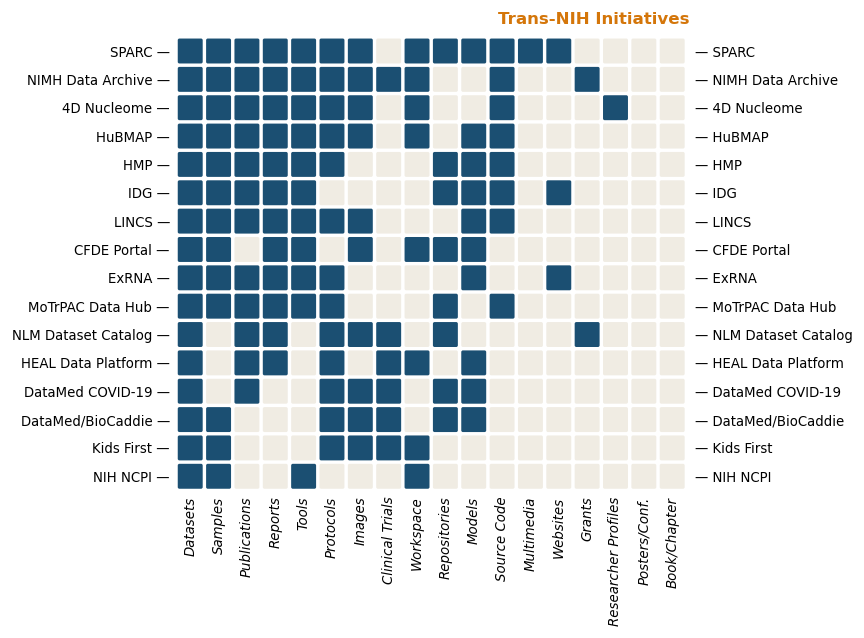

Saved: results/heatmap_icwide_platforms.png


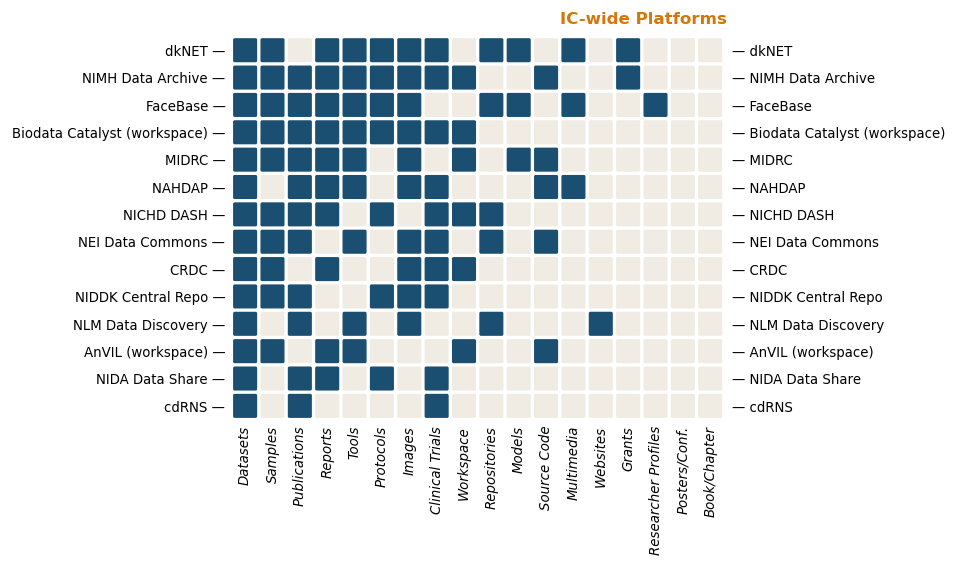

In [2]:
from matplotlib.patches import FancyBboxPatch
import os
os.makedirs('results', exist_ok=True)

short_resource_map = {
    'Institution/Researcher Profiles': 'Researcher Profiles',
    'Posters/Conference Contribution': 'Posters/Conf.',
    'Reports/Analyses': 'Reports',
    'Book/Chapter/Collection': 'Book/Chapter',
    'Software Source Code': 'Source Code',
}

resource_sums = df[resource_cols].sum().sort_values(ascending=False)
sorted_resource_cols = resource_sums.index.tolist()
sorted_short_resource = [short_resource_map.get(c, c) for c in sorted_resource_cols]

df['_ResourceCount'] = df[resource_cols].sum(axis=1)

is_trans = df['Type'].str.lower().str.contains('trans')
is_ic = df['Type'].str.lower().str.contains('ic-wide')

subsets = [
    ('Trans-NIH Initiatives', df[is_trans].sort_values('_ResourceCount', ascending=False)),
    ('IC-wide Platforms', df[is_ic].sort_values('_ResourceCount', ascending=False)),
]

fill_color = '#1b4f72'
empty_color = '#f0ece3'
cell_size = 0.2
square_size = 0.88
rounding = 0.06

def plot_heatmap(title_label, df_sub, save_path=None, dpi=300):
    n_rows = len(df_sub)
    n_cols = len(sorted_resource_cols)
    fig_w = n_cols * cell_size + 3.5
    fig_h = n_rows * cell_size + 2
    matrix = df_sub.set_index('ShortName')[sorted_resource_cols].values.astype(float)
    names = df_sub['ShortName'].values

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.set_facecolor('white')
    fig.set_facecolor('white')

    for i in range(n_rows):
        for j in range(n_cols):
            color = fill_color if matrix[i, j] == 1 else empty_color
            box = FancyBboxPatch(
                (j - square_size/2, i - square_size/2),
                square_size, square_size,
                boxstyle=f'round,pad=0,rounding_size={rounding}',
                facecolor=color, edgecolor='none')
            ax.add_patch(box)

    ax.set_xlim(-0.6, n_cols - 0.4)
    ax.set_ylim(n_rows - 0.4, -0.6)
    ax.set_aspect('equal')

    ax.set_xticks(range(n_cols))
    ax.set_xticklabels(sorted_short_resource, rotation=90, ha='center',
                       fontsize=8, fontstyle='italic')

    ax.set_yticks(range(n_rows))
    ax.set_yticklabels([f'{n} —' for n in names], fontsize=8, ha='right')

    ax2 = ax.secondary_yaxis('right')
    ax2.set_yticks(range(n_rows))
    ax2.set_yticklabels([f'— {n}' for n in names], fontsize=8, ha='left')
    ax2.tick_params(length=0)

    for spine in ax.spines.values():
        spine.set_visible(False)
    for spine in ax2.spines.values():
        spine.set_visible(False)
    ax.tick_params(axis='both', length=0, pad=2)

    ax.set_title(title_label, fontsize=10, fontweight='bold',
                 color='#d4760a', loc='right', pad=6)

    plt.tight_layout(pad=0.3)
    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches='tight', facecolor='white')
        print(f'Saved: {save_path}')
    plt.show()

for title_label, df_sub in subsets:
    slug = title_label.lower().replace(' ', '_').replace('-', '')
    plot_heatmap(title_label, df_sub, save_path=f'results/heatmap_{slug}.png')

## Breadth of Resource Types per Platform

Saved: results/breadth_transnih_initiatives.png


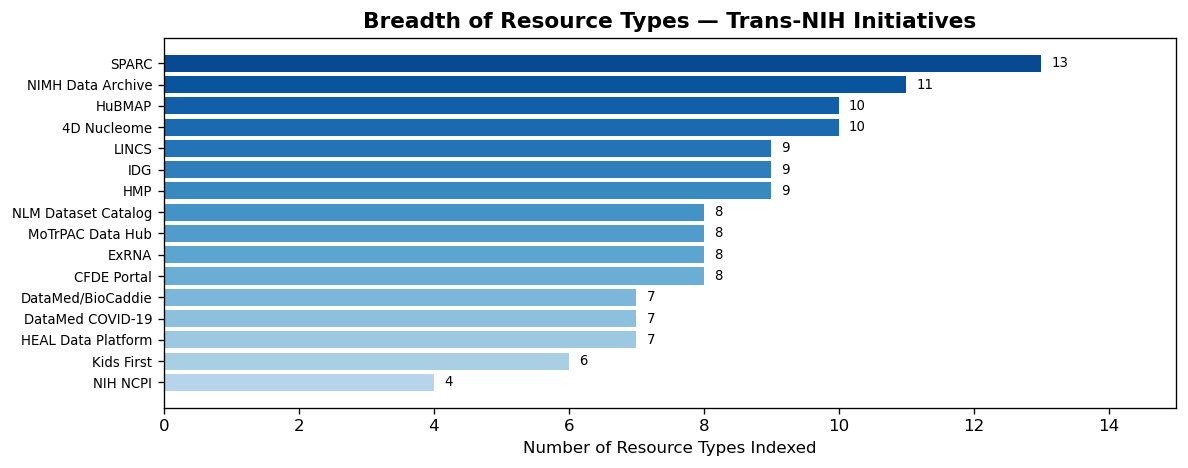

Saved: results/breadth_icwide_platforms.png


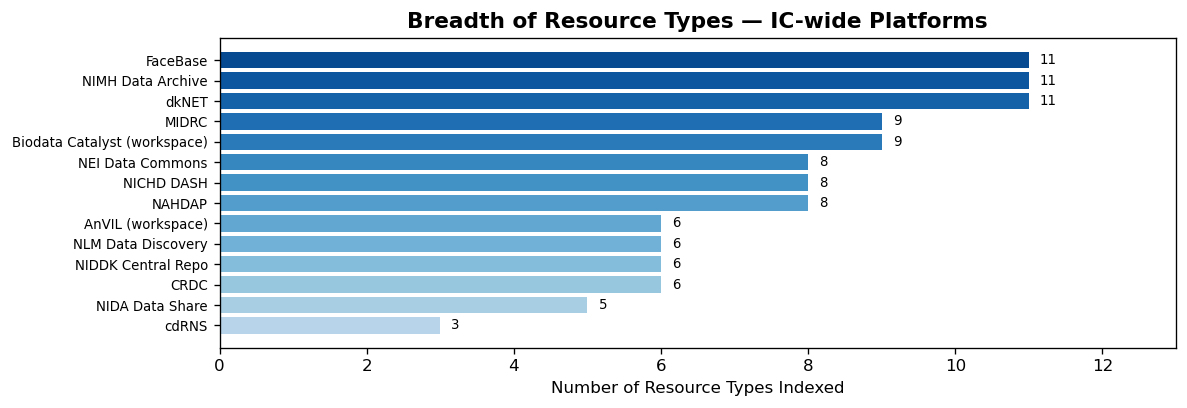

In [12]:
df['ResourceCount'] = df[resource_cols].sum(axis=1)

is_trans = df['Type'].str.lower().str.contains('trans')
is_ic = df['Type'].str.lower().str.contains('ic-wide')

breadth_subsets = [
    ('Trans-NIH Initiatives', df[is_trans].sort_values('ResourceCount', ascending=True)),
    ('IC-wide Platforms', df[is_ic].sort_values('ResourceCount', ascending=True)),
]

def plot_breadth(title_label, df_sub, save_path=None, dpi=300):
    fig, ax = plt.subplots(figsize=(10, max(3, len(df_sub) * 0.25)))
    colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(df_sub)))
    ax.barh(range(len(df_sub)), df_sub['ResourceCount'], color=colors)
    ax.set_yticks(range(len(df_sub)))
    ax.set_yticklabels(df_sub['ShortName'], fontsize=8)
    ax.set_xlabel('Number of Resource Types Indexed')
    ax.set_title(f'Breadth of Resource Types — {title_label}', fontsize=13, fontweight='bold')
    for i, v in enumerate(df_sub['ResourceCount']):
        ax.text(v + 0.15, i, str(int(v)), va='center', fontsize=8)
    ax.set_xlim(0, df_sub['ResourceCount'].max() + 2)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches='tight', facecolor='white')
        print(f'Saved: {save_path}')
    plt.show()

for title_label, df_sub in breadth_subsets:
    slug = title_label.lower().replace(' ', '_').replace('-', '')
    plot_breadth(title_label, df_sub, save_path=f'results/breadth_{slug}.png')

## Prevalence of Each Resource Type Across Platforms

Saved: results/resource_prevalence.png


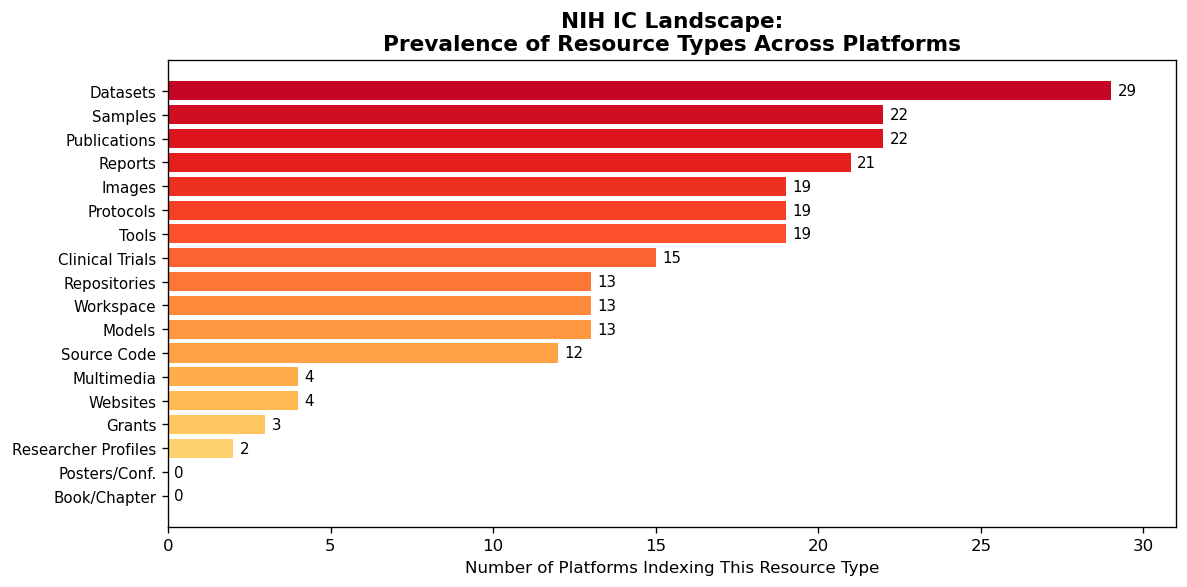

In [16]:
resource_counts = df[resource_cols].sum().sort_values(ascending=True)
short_labels = [c.replace('Institution/Researcher Profiles', 'Researcher Profiles')
                 .replace('Posters/Conference Contribution', 'Posters/Conf.')
                 .replace('Reports/Analyses', 'Reports')
                 .replace('Book/Chapter/Collection', 'Book/Chapter')
                 .replace('Software Source Code', 'Source Code')
                 for c in resource_counts.index]

def plot_prevalence(save_path=None, dpi=300):
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = plt.cm.YlOrRd(np.linspace(0.2, 0.85, len(resource_counts)))
    ax.barh(range(len(resource_counts)), resource_counts.values, color=colors)
    ax.set_yticks(range(len(resource_counts)))
    ax.set_yticklabels(short_labels, fontsize=9)
    ax.set_xlabel('Number of Platforms Indexing This Resource Type')
    ax.set_title('NIH IC Landscape:\nPrevalence of Resource Types Across Platforms', fontsize=13, fontweight='bold')
    for i, v in enumerate(resource_counts.values):
        ax.text(v + 0.2, i, str(int(v)), va='center', fontsize=9)
    ax.set_xlim(0, resource_counts.max() + 2)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches='tight', facecolor='white')
        print(f'Saved: {save_path}')
    plt.show()

plot_prevalence(save_path='results/resource_prevalence.png')

## Platform Feature Adoption & Type Breakdown

In [ ]:
feature_cols_no_uptime = [
    'API', 'Search',
    'Metadata/data standardization', 'Metadata/data validation',
    'Metadata augmentation'
]
feature_labels = ['API', 'Search', 'Metadata\nStandard.', 'Metadata\nValidation', 'Metadata\nAugment.']
feature_totals = df[feature_cols_no_uptime].sum()

type_simple = []
for t in df['Type']:
    if 'trans' in str(t).lower():
        type_simple.append('Trans-NIH')
    elif 'ic-wide' in str(t).lower():
        type_simple.append('IC-wide')
    else:
        type_simple.append(str(t))
df['TypeSimple'] = type_simple

def plot_features_and_types(save_path=None, dpi=300):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    colors_feat = ['#4292c6', '#2171b5', '#fd8d3c', '#e6550d', '#a63603']
    ax.bar(range(len(feature_totals)), feature_totals.values, color=colors_feat)
    ax.set_xticks(range(len(feature_labels)))
    ax.set_xticklabels(feature_labels, fontsize=9)
    ax.set_ylabel('Number of Platforms')
    ax.set_title('Platform Feature Adoption', fontsize=12, fontweight='bold')
    for i, v in enumerate(feature_totals.values):
        ax.text(i, v + 0.3, str(int(v)), ha='center', fontsize=10, fontweight='bold')
    ax.set_ylim(0, feature_totals.max() + 3)

    ax2 = axes[1]
    type_simple_counts = df['TypeSimple'].value_counts()
    wedge_colors = plt.cm.Set2(np.linspace(0, 1, len(type_simple_counts)))
    ax2.pie(type_simple_counts.values, labels=type_simple_counts.index,
            autopct='%1.0f%%', colors=wedge_colors, textprops={'fontsize': 9})
    ax2.set_title('Platform Types', fontsize=12, fontweight='bold')

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches='tight', facecolor='white')
        print(f'Saved: {save_path}')
    plt.show()

plot_features_and_types(save_path='results/features_and_types.png')

## NIH Institutes/Centers with Data Ecosystem Platforms

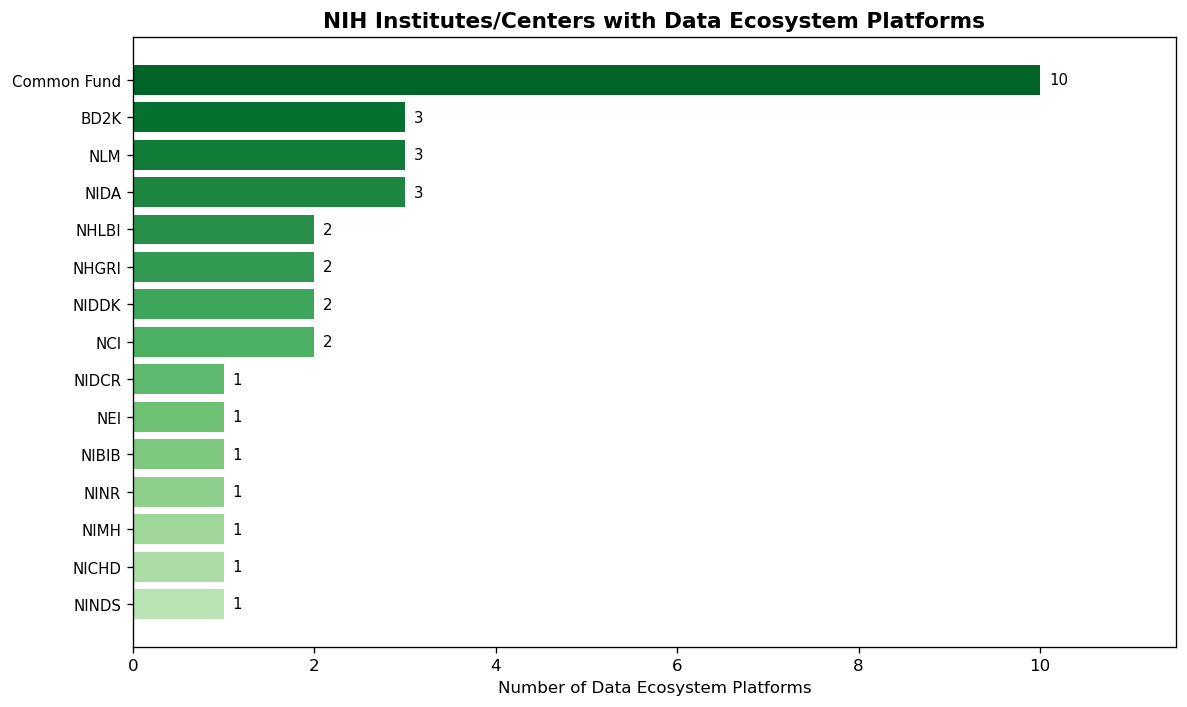

In [6]:
ic_list = []
for _, row in df.iterrows():
    ics = str(row['IC']).split(',')
    for ic in ics:
        ic = ic.strip()
        if ic and ic != 'None':
            ic_list.append(ic)
ic_series = pd.Series(ic_list).value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors_ic = plt.cm.Greens(np.linspace(0.3, 0.9, len(ic_series)))
ax.barh(range(len(ic_series)), ic_series.values, color=colors_ic)
ax.set_yticks(range(len(ic_series)))
ax.set_yticklabels(ic_series.index, fontsize=9)
ax.set_xlabel('Number of Data Ecosystem Platforms')
ax.set_title('NIH Institutes/Centers with Data Ecosystem Platforms', fontsize=13, fontweight='bold')
for i, v in enumerate(ic_series.values):
    ax.text(v + 0.1, i, str(int(v)), va='center', fontsize=9)
ax.set_xlim(0, ic_series.max() + 1.5)
plt.tight_layout()
plt.show()